In [1]:
import sys

sys.path.insert(0, '../code')

In [2]:
from catalog import get_nexsci_data

table_name = 'pscomppars'
df_nexsci = get_nexsci_data(table_name, clobber=False)
df_nexsci.shape

2025-08-06 20:55:10.821 | INFO     | catalog:get_nexsci_data:1367 - Column definitions: 
/mnt_ut2/raid_ut2/home/jerome/github/research/project/wakai/notebooks/../code/catalog.py:1378: DtypeWarning: Columns (5,6,127,130,350,353,368,396,399,405,408) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)
2025-08-06 20:55:12.129 | INFO     | catalog:get_nexsci_data:1379 - Loaded: 


(4279, 684)

In [3]:
# get values from default references
if table_name=="ps":
    idx = df_nexsci['default_flag'] == 1
    all_hostnames = df_nexsci[idx].hostname.unique()
    
    #TOI-1136
    idx = df_nexsci[df_nexsci.hostname=="TOI-1136"][df_nexsci[df_nexsci.hostname=="TOI-1136"].pl_refname.str.contains("Dai")].index
    df_nexsci.loc[idx,'default_flag']=1
else:
    all_hostnames = df_nexsci.hostname.unique()
len(all_hostnames)

3237

In [4]:
import astropy.units as u

# get only transiting planets
df_nexsci['pl_rade'] = df_nexsci['pl_radj']*u.Rjup.to(u.Rearth)

# filter data
idx = (df_nexsci.pl_orbper>0) & \
        (df_nexsci.pl_rade>0) & \
        (df_nexsci.st_mass>0) & \
        (df_nexsci.discoverymethod.isin(['Transit','Radial Velocity'])) #& \
        # (df_nexsci['default_flag'] == 1)
df = df_nexsci[idx]
df.shape

(4279, 684)

In [5]:
import pandas as pd

df_age = pd.read_excel("/ut2/jerome/github/research/project/TOI-6715/data/young_validated_planets_TOIs.xlsx", 
                         sheet_name='validated_hosts', 
                         skiprows=[1]).dropna(subset=['Host'])
df_age = df_age.iloc[:68]
df_age = df_age.reset_index(drop=True)
df_age.shape

(68, 38)

In [6]:
df_age['hostname'] = df_age.Host.apply(lambda x: str(x).lower().replace(' ', ''))
young_hostnames = df_age['hostname'].reset_index(drop=True)
young_hostnames

0     iras04125+2902
1              k2-33
2           toi-1227
3           hd114082
4           hip67522
           ...      
63     epic211822797
64            k2-104
65            k2-264
66            k2-284
67            k2-233
Name: hostname, Length: 68, dtype: object

In [7]:
# add a column for edited hostname
df['hostname'] = df.hostname.apply(lambda x: x.lower().replace(' ', ''))

In [8]:
# cross-match NExSci data with own my list based on (edited) hostname
idx = df['hostname'].isin(young_hostnames)
df_young_planets = df[idx]
df_young_planets.shape

(93, 684)

In [9]:
df_young_hosts = df_young_planets.drop_duplicates(subset='hostname', keep='first')
df_young_hosts.shape

(58, 684)

In [10]:
#planets in my list not found in NExSci
found=df['hostname'][idx].tolist()
#missing
young_hostnames[~young_hostnames.isin(found)]

0     iras04125+2902
3           hd114082
5            ngts-33
6        tic88785435
14             dstuc
17          koi-7913
18       tic43439883
40          toi-1027
43          toi-5734
57          toi-4364
Name: hostname, dtype: object

In [11]:
idx=df_age.query("hostname=='toi-5734'").index
df_age = df_age.drop(index=idx)

In [12]:
df_age['Age_lower'] = df_age['Age'].apply(lambda x: str(x).split('-')[0]).astype(float).values
df_age['Age_upper'] = df_age['Age'].apply(lambda x: str(x).split('-')[1]).astype(float).values
df_age['age_median'] = df_age[['Age_lower','Age_upper']].mean(axis=1)

In [13]:
star_params_names = ['st_rad','st_raderr1',
                     'st_mass','st_masserr1',
                     'st_teff','st_tefferr1',
                     'st_logg','st_loggerr1',
                     'st_met','st_meterr1',
                    ]
df_young_hosts[['hostname']+star_params_names].tail()

,hostname,st_rad,st_raderr1,st_mass,st_masserr1,st_teff,st_tefferr1,st_logg,st_loggerr1,st_met,st_meterr1
3610,kepler-1561,1.11,0.27,1.07,0.12,5957.0,196.63,4.38,0.10,0.04,0.145
3757,k2-33,1.05,0.07,0.56,0.09,3540.0,70.00,4.06,0.18,NaN,NaN
3832,kepler-1565,0.73,0.04,0.76,0.04,4940.0,81.88,4.60,0.04,-0.16,0.161
3863,kepler-1627,0.84,0.09,0.87,0.05,5445.0,93.89,4.54,0.05,-0.10,0.161
4168,kepler-1928,0.92,0.04,1.01,0.03,5720.0,60.00,4.53,0.02,0.12,0.020


In [14]:
mag_columns = ['sy_jmag', 'sy_jmagerr1',
               'sy_hmag', 'sy_hmagerr1',
               'sy_kmag', 'sy_kmagerr1',
               'sy_gaiamag', 'sy_gaiamagerr1',
               'sy_w1mag', 'sy_w1magerr1',
               'sy_w2mag', 'sy_w2magerr1',
               'sy_w3mag', 'sy_w3magerr1',
               'sy_dist', 'sy_disterr1'
            ]
df_young_hosts[['hostname']+mag_columns].tail()

,hostname,sy_jmag,sy_jmagerr1,sy_hmag,sy_hmagerr1,sy_kmag,sy_kmagerr1,sy_gaiamag,sy_gaiamagerr1,sy_w1mag,sy_w1magerr1,sy_w2mag,sy_w2magerr1,sy_w3mag,sy_w3magerr1,sy_dist,sy_disterr1
3610,kepler-1561,13.453,0.025,13.116,0.026,13.053,0.029,14.6480,0.000563,12.977,0.024,13.020,0.028,12.356,0.251,839.076,18.935
3757,k2-33,11.095,0.023,10.332,0.022,10.026,0.019,14.1570,0.000900,9.890,0.023,9.762,0.021,9.610,0.049,139.268,1.532
3832,kepler-1565,13.917,0.035,13.318,0.031,13.259,0.033,15.4317,0.001653,NaN,NaN,NaN,NaN,NaN,NaN,629.930,11.596
3863,kepler-1627,11.690,0.021,11.298,0.022,11.194,0.018,13.0492,0.002012,11.148,0.023,11.145,0.021,11.025,0.087,317.437,4.528
4168,kepler-1928,11.456,0.020,11.152,0.016,11.107,0.019,12.6182,0.000651,11.060,0.023,11.093,0.020,10.913,0.094,326.362,2.473


In [15]:
input_cols = ['hostname']+star_params_names+mag_columns
df_benchmark = df_young_hosts[input_cols].dropna(how='any')
df_benchmark.shape

(46, 27)

In [16]:
df_benchmark = pd.merge(df_benchmark, df_age[['hostname','age_median']], on='hostname')

In [17]:
df_benchmark.to_csv('../data/benchmark_host_params.csv', index=False)

In [18]:
import pandas as pd

df_input = pd.read_csv('../data/benchmark_host_params.csv')
df_input.tail()

,hostname,st_rad,st_raderr1,st_mass,st_masserr1,st_teff,st_tefferr1,st_logg,st_loggerr1,st_met,...,sy_gaiamagerr1,sy_w1mag,sy_w1magerr1,sy_w2mag,sy_w2magerr1,sy_w3mag,sy_w3magerr1,sy_dist,sy_disterr1,age_median
41,hd235088,0.80,0.03,0.85,0.02,5087.0,63.00,4.56,0.02,0.105,...,0.000387,6.995,0.050,7.095,0.020,7.075,0.016,41.1706,0.0414,700.0
42,epic211822797,0.58,0.01,0.62,0.02,4057.0,37.00,4.70,0.01,0.200,...,0.000323,11.341,0.022,11.349,0.021,11.503,0.327,186.1970,1.3645,700.0
43,kepler-1561,1.11,0.27,1.07,0.12,5957.0,196.63,4.38,0.10,0.040,...,0.000563,12.977,0.024,13.020,0.028,12.356,0.251,839.0760,18.9350,421.0
44,kepler-1627,0.84,0.09,0.87,0.05,5445.0,93.89,4.54,0.05,-0.100,...,0.002012,11.148,0.023,11.145,0.021,11.025,0.087,317.4370,4.5280,38.0
45,kepler-1928,0.92,0.04,1.01,0.03,5720.0,60.00,4.53,0.02,0.120,...,0.000651,11.060,0.023,11.093,0.020,10.913,0.094,326.3620,2.4730,105.0


## star.ini

In [30]:
from pathlib import Path
import numpy as np

outdir = '../isochrones'
mag_cols = 'j h k gaia'.split()
add_spec_priors = True

cmd = []
for i,row in df_input.iterrows():
    prefix = 'with' if add_spec_priors else 'wo'
    p = Path(outdir, row.hostname, f'{prefix}_spec_priors')
    if not p.exists():
        p.mkdir(parents=True)
    fp = p.joinpath('star.ini')
    
    #print(i)
    text = []
    text.append(f"#{row.hostname}")
    plx_err = 1000*(row.sy_disterr1/row.sy_dist**2)
    plx_err = plx_err if plx_err > 0.01 else 0.01
    text.append(f"parallax = {1000/row.sy_dist:.2f}, {plx_err:.2f}")
    for j in mag_cols:
        v = f'sy_{j}mag'
        mag_err = row[v+'err1'] if float(row[v+'err1'])>0.01 else 0.01
        b = j[0] if j=='gaia' else j
        text.append(f"{b.upper()} = {row[v]:.3f}, {mag_err:.3f}")
    if add_spec_priors:
        text.append(f"Teff = {row['st_teff']:.0f}, {row['st_tefferr1']:.0f}")
        text.append(f"logg = {row['st_logg']:.2f}, {row['st_loggerr1']:.2f}")
        text.append(f"feh = {row['st_met']:.2f}, {row['st_meterr1']:.2f}")
    np.savetxt(fp, text, fmt='%s')

## mkbf

In [31]:
cmd = []
for i,row in df_input.iterrows():
    prefix = 'with' if add_spec_priors else 'wo'
    p = Path(outdir, row.hostname, f'{prefix}_spec_priors')
    cmd.append(f"cd {p} && starfit -o")
fp = Path(outdir, f'starfit_{prefix}_spec_priors.batch')
np.savetxt(fp, cmd, fmt='%s')

## corner

/ut3/jerome/miniconda3/envs/wakai/lib/python3.12/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step


Axis limits cannot be NaN or Inf


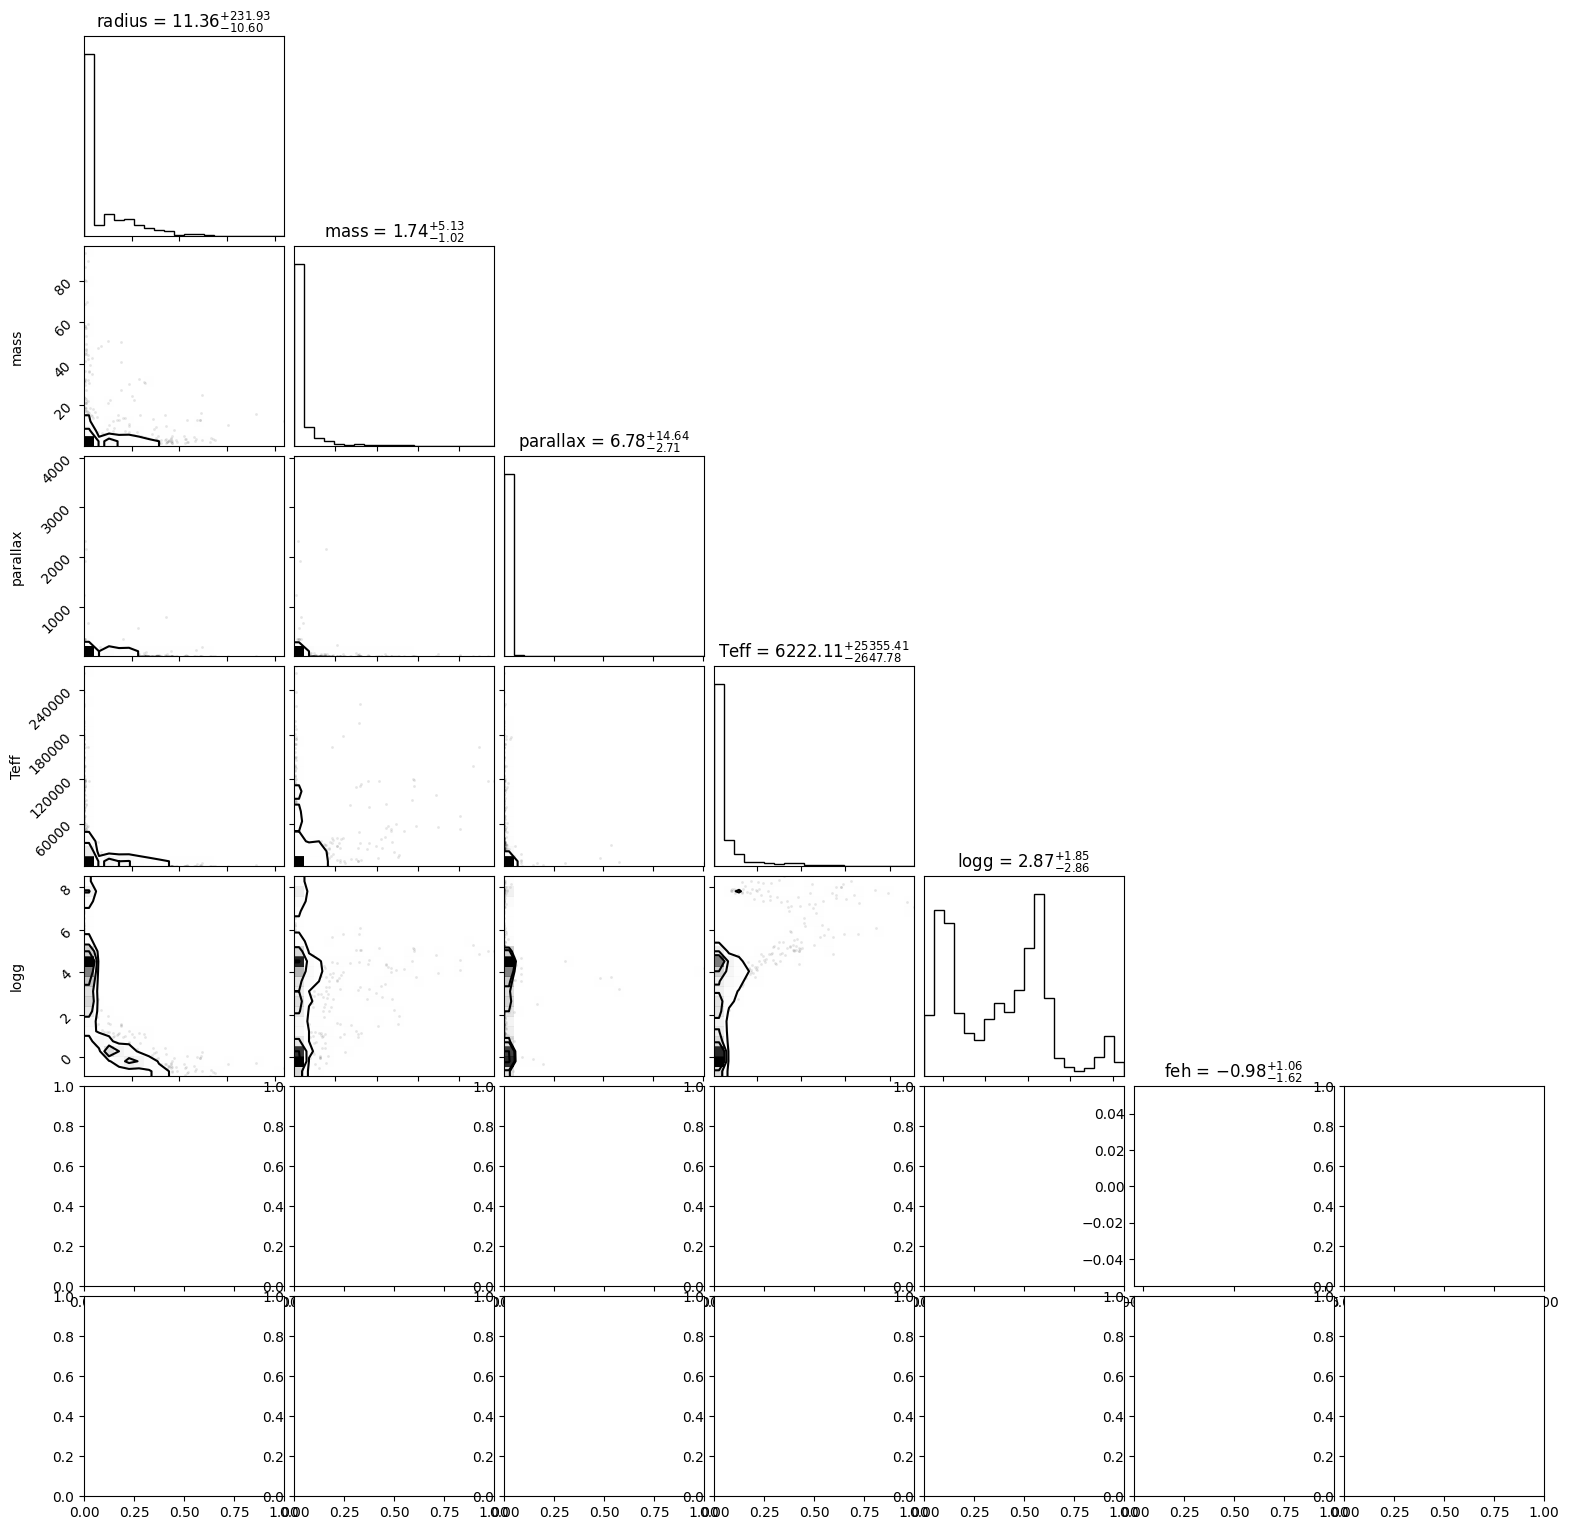

In [89]:
from corner import corner

add_spec_priors = True
cols = ['radius','mass','parallax','Teff','logg','feh','age']
clobber = False

for i,row in df_input.iterrows():
    # print(row.hostname)
    d = df_input.query(f"hostname=='{row.hostname}'").squeeze()
    prefix = 'with' if add_spec_priors else 'wo'
    p = Path(outdir, row.hostname, f'{prefix}_spec_priors')
    fp = p.joinpath('mist_starmodel_single.h5')
    df_samples = pd.read_hdf(fp, 'derived_samples')

    fp_png = p.joinpath('mist_corner.png')
    fp_txt = p.joinpath('star_params_comparison.txt')

    truths = [
            d.st_rad, 
            d.st_mass,
            1000/d.sy_dist,
            d.st_teff,
            d.st_logg,
            d.st_met,
            np.log10(d.age_median*1e6)
        ]
    s1=df_samples[cols].median(axis=0)
    s1.name = 'iso'
    s2 = pd.Series(truths, index=cols)
    s2.name = 'ref'
    r = pd.concat([s1, s2], axis=1)
    r.to_csv(fp_txt, float_format="%.2f")

    if not fp_png.exists() or clobber:
        try:
            fig = corner(df_samples[cols], 
                     show_titles="%.2f",
                     truths=truths,
                     labels=cols)
            fig.suptitle(row.hostname.upper())
            fig.savefig(fp_png)
        except Exception as e:
            print(e)

## comparison

/ut3/jerome/miniconda3/envs/wakai/lib/python3.12/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step


Axis limits cannot be NaN or Inf


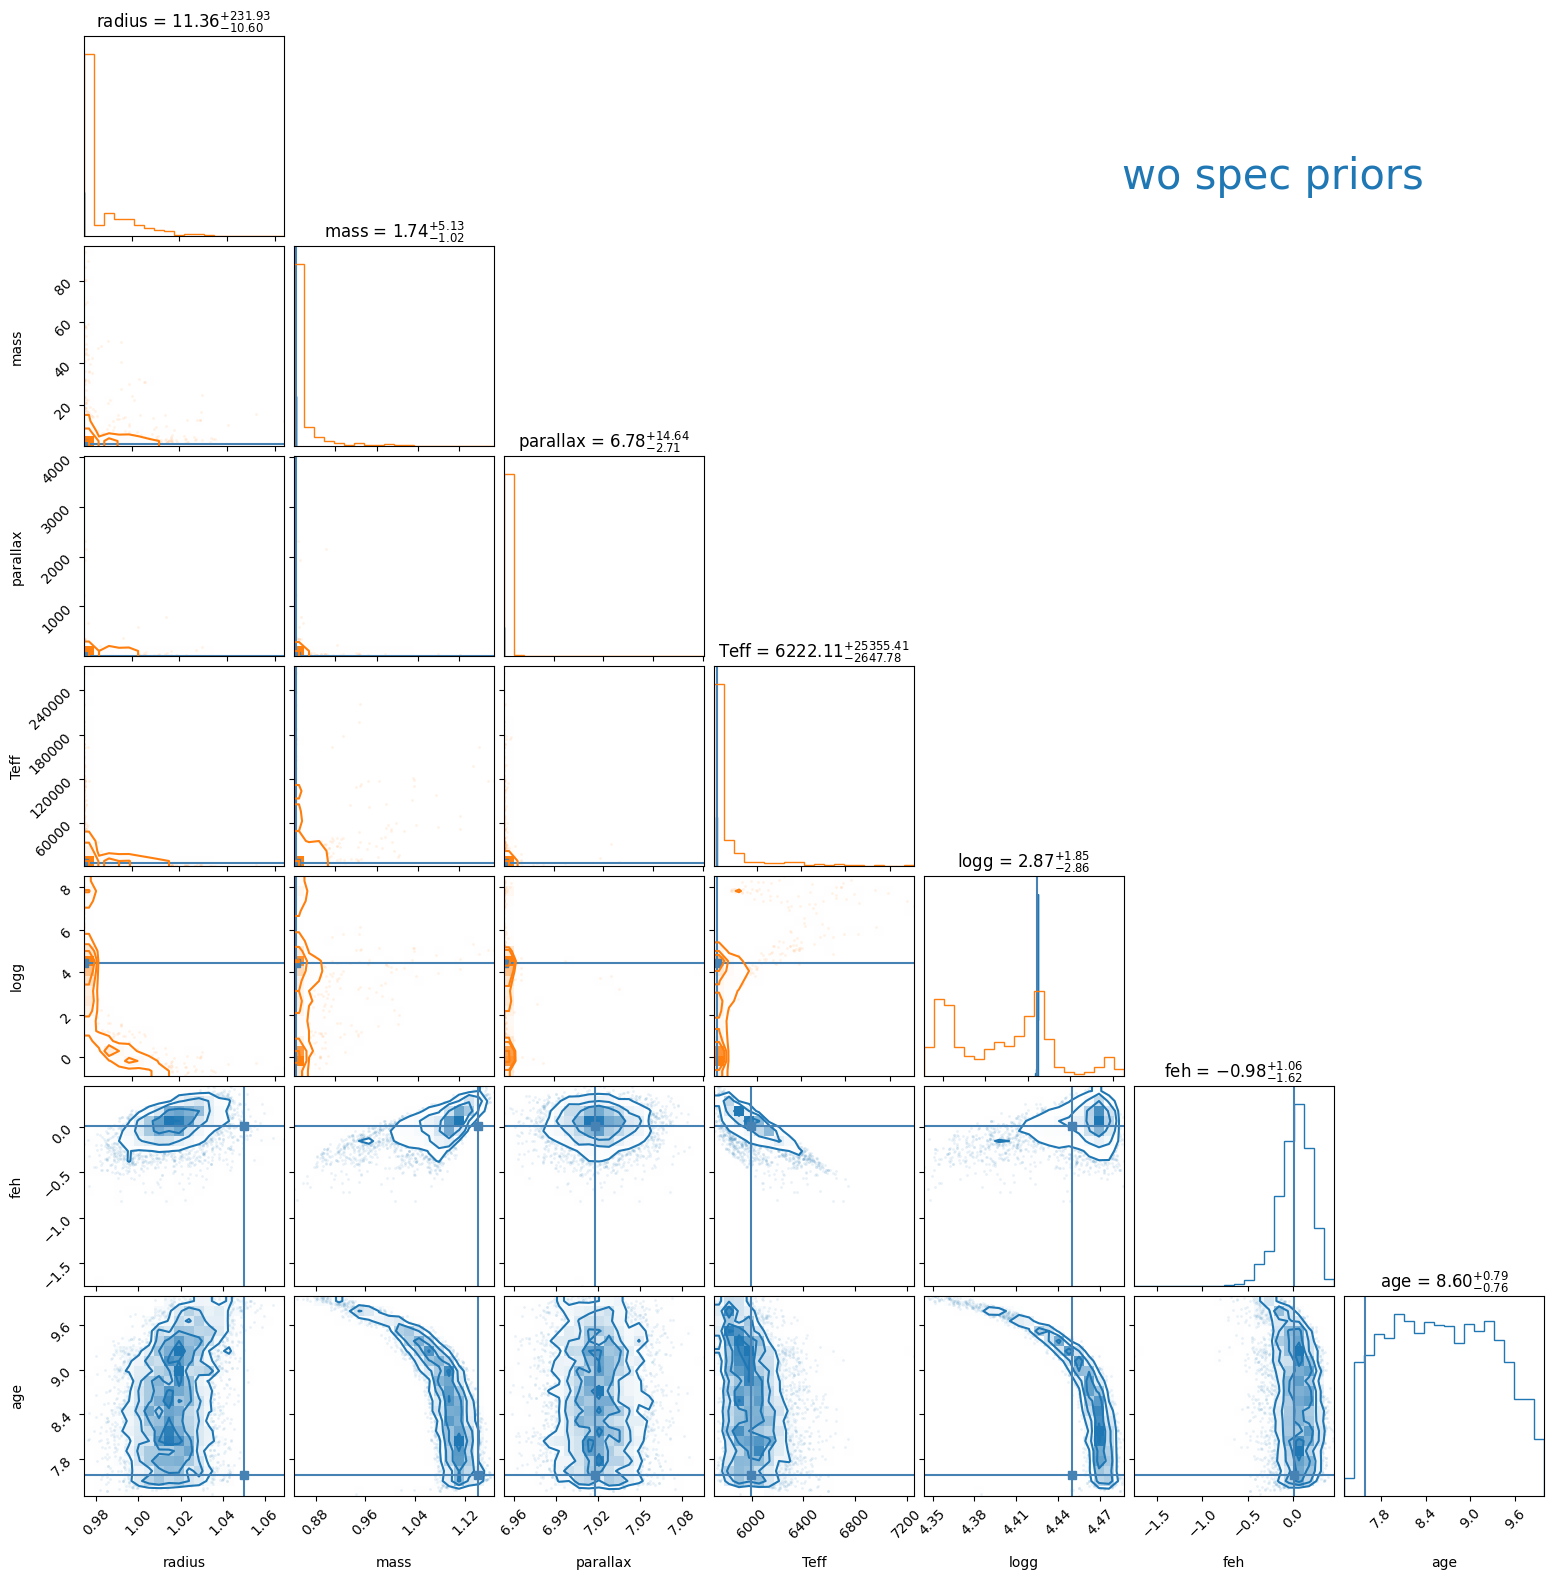

In [62]:
from corner import corner

cols = ['radius','mass','parallax','Teff','logg','feh','age']
overwrite = False

data = {}
for i,row in df_input.iterrows():
    # print(row.hostname)
    d = df_input.query(f"hostname=='{row.hostname}'").squeeze()
    label1 = 'wo_spec_priors'
    p1 = Path(outdir, row.hostname, label1)
    fp1 = p1.joinpath('mist_starmodel_single.h5')
    df_samples1 = pd.read_hdf(fp1, 'derived_samples')
    label2 = 'with_spec_priors'
    p2 = Path(outdir, row.hostname, label2)
    fp2 = p2.joinpath('mist_starmodel_single.h5')
    df_samples2 = pd.read_hdf(fp2, 'derived_samples')
    
    fp_png = Path(outdir, row.hostname,'mist_corner_comparison.png')
    if not fp_png.exists() or overwrite:
        truths = [
            d.st_rad, 
            d.st_mass,
            1000/d.sy_dist,
            d.st_teff,
            d.st_logg,
            d.st_met,
            np.log10(d.age_median*1e6)
        ]
        try:
            fig = corner(df_samples1[cols], 
                         show_titles="%.2f",
                         truths=truths,
                         labels=cols,
                         weights=np.ones(len(df_samples1))/len(df_samples1), 
                         color='C0'
                        )
            fig.text(0.9, 0.9, label1.replace('_',' '), ha='right', va='top', color='C0', fontsize=30)
            _ = corner(df_samples2[cols], 
                        show_titles="%.2f",
                        truths=truths,
                        labels=cols,
                        weights=np.ones(len(df_samples2))/len(df_samples2), 
                        color='C1',
                        fig=fig
                        )
            fig.text(0.9, 0.85, label2.replace('_',' '), ha='right', va='top', color='C1', fontsize=30)
            fig.suptitle(row.hostname.upper())
            fig.savefig(fp_png)
        except Exception as e:
            print(e)

In [109]:
sys.path.insert(0, '/ut2/jerome/github/research/project/TOI-6715')

from toi6715 import load_plot_params
plot_params = load_plot_params()

Text(0.5, 1.0, 'radius ($R_{\\odot}$)')

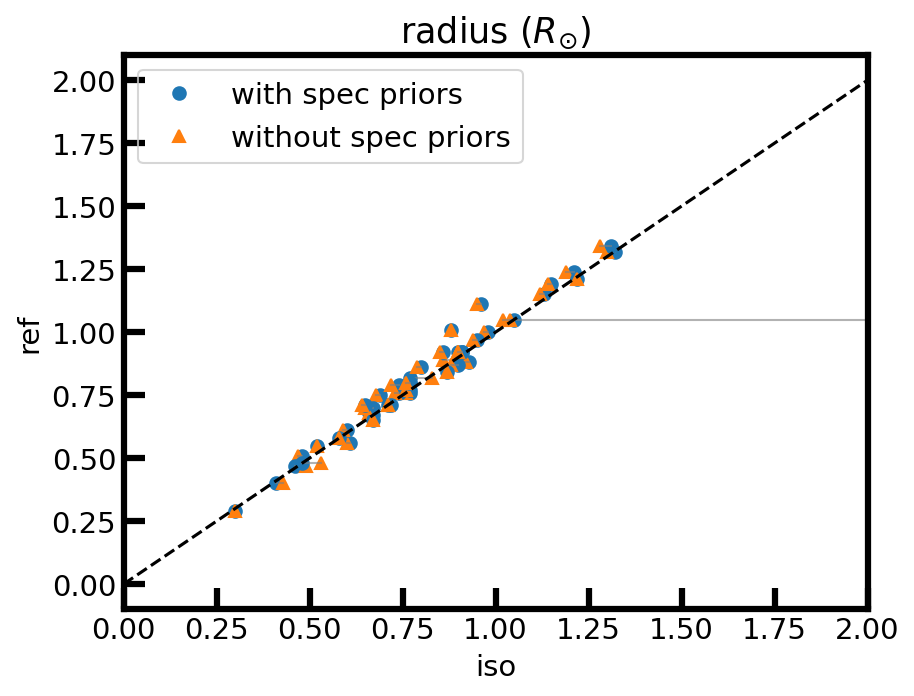

In [110]:
import matplotlib.pyplot as pl

param = 'radius'
unit = r'$R_{\odot}$'

for i,row in df_input.iterrows():
    p1 = Path(outdir, row.hostname, 'with_spec_priors')
    fp_txt1 = p1.joinpath('star_params_comparison.txt')
    r1 = pd.read_csv(fp_txt1, index_col=0)
    label1 = 'with spec priors' if i==0 else '_nolegend_'
    pl.plot(*r1.T[param], 'o', label=label1, c='C0')

    p2 = Path(outdir, row.hostname, 'wo_spec_priors')
    fp_txt2 = p2.joinpath('star_params_comparison.txt')
    r2 = pd.read_csv(fp_txt2, index_col=0)
    label2 = 'without spec priors' if i==0 else '_nolegend_'
    pl.plot(*r2.T[param], '^', label=label2, c='C1')

    # Add line connecting the two points
    x_vals = [r1.T[param].iloc[0], r2.T[param].iloc[0]]
    y_vals = [r1.T[param].iloc[1], r2.T[param].iloc[1]]
    pl.plot(x_vals, y_vals, c='gray', lw=1, alpha=0.6)
pl.legend()
x = np.linspace(0, 2, 100)
pl.plot(x, x, ls='--', c='k')
pl.xlim(0, 2)
pl.xlabel(r1.T[param].index[0])
pl.ylabel(r1.T[param].index[1])
pl.title(f"{param} ({unit})")

Text(0.5, 1.0, 'log10(age) (y)')

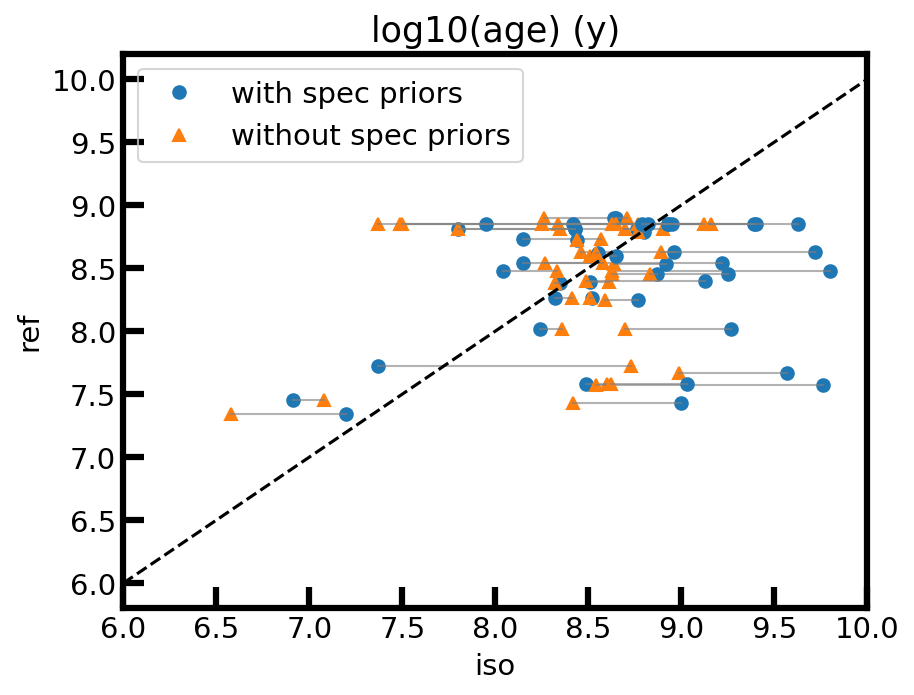

In [123]:
import matplotlib.pyplot as pl

param = 'age'
unit = 'y'

for i,row in df_input.iterrows():
    p1 = Path(outdir, row.hostname, 'with_spec_priors')
    fp_txt1 = p1.joinpath('star_params_comparison.txt')
    r1 = pd.read_csv(fp_txt1, index_col=0)
    label1 = 'with spec priors' if i==0 else '_nolegend_'
    pl.plot(*r1.T[param], 'o', label=label1, c='C0')

    p2 = Path(outdir, row.hostname, 'wo_spec_priors')
    fp_txt2 = p2.joinpath('star_params_comparison.txt')
    r2 = pd.read_csv(fp_txt2, index_col=0)
    label2 = 'without spec priors' if i==0 else '_nolegend_'
    pl.plot(*r2.T[param], '^', label=label2, c='C1')

    # Add line connecting the two points
    x_vals = [r1.T[param].iloc[0], r2.T[param].iloc[0]]
    y_vals = [r1.T[param].iloc[1], r2.T[param].iloc[1]]
    pl.plot(x_vals, y_vals, c='gray', lw=1, alpha=0.6)
pl.legend()
x = np.linspace(6, 10, 100)
pl.plot(x, x, ls='--', c='k')
pl.xlim(6, 10)
pl.xlabel(r1.T[param].index[0])
pl.ylabel(r1.T[param].index[1])
pl.title(f"log10(age) ({unit})")

Text(0.5, 1.0, 'mass ($M_{\\odot}$)')

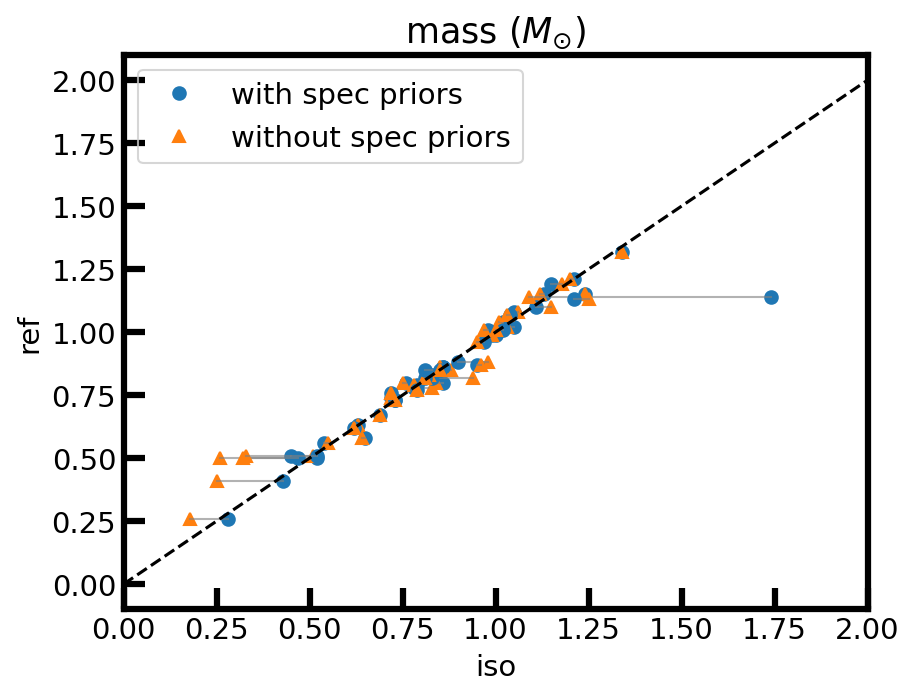

In [111]:
import matplotlib.pyplot as pl

param = 'mass'
unit = r'$M_{\odot}$'

for i,row in df_input.iterrows():
    p1 = Path(outdir, row.hostname, 'with_spec_priors')
    fp_txt1 = p1.joinpath('star_params_comparison.txt')
    r1 = pd.read_csv(fp_txt1, index_col=0)
    label1 = 'with spec priors' if i==0 else '_nolegend_'
    pl.plot(*r1.T[param], 'o', label=label1, c='C0')

    p2 = Path(outdir, row.hostname, 'wo_spec_priors')
    fp_txt2 = p2.joinpath('star_params_comparison.txt')
    r2 = pd.read_csv(fp_txt2, index_col=0)
    label2 = 'without spec priors' if i==0 else '_nolegend_'
    pl.plot(*r2.T[param], '^', label=label2, c='C1')

    # Add line connecting the two points
    x_vals = [r1.T[param].iloc[0], r2.T[param].iloc[0]]
    y_vals = [r1.T[param].iloc[1], r2.T[param].iloc[1]]
    pl.plot(x_vals, y_vals, c='gray', lw=1, alpha=0.6)
pl.legend()
x = np.linspace(0, 2, 100)
pl.plot(x, x, ls='--', c='k')
pl.xlim(0, 2)
pl.xlabel(r1.T[param].index[0])
pl.ylabel(r1.T[param].index[1])
pl.title(f"{param} ({unit})")

Text(0.5, 1.0, 'logg (cgs)')

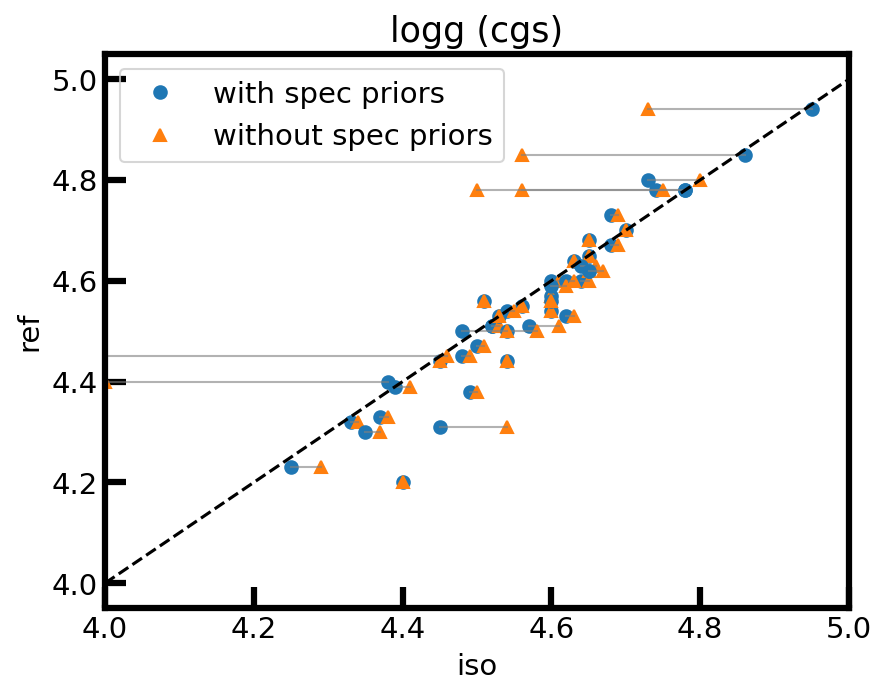

In [114]:
import matplotlib.pyplot as pl

param = 'logg'
unit = 'cgs'

for i,row in df_input.iterrows():
    p1 = Path(outdir, row.hostname, 'with_spec_priors')
    fp_txt1 = p1.joinpath('star_params_comparison.txt')
    r1 = pd.read_csv(fp_txt1, index_col=0)
    label1 = 'with spec priors' if i==0 else '_nolegend_'
    pl.plot(*r1.T[param], 'o', label=label1, c='C0')

    p2 = Path(outdir, row.hostname, 'wo_spec_priors')
    fp_txt2 = p2.joinpath('star_params_comparison.txt')
    r2 = pd.read_csv(fp_txt2, index_col=0)
    label2 = 'without spec priors' if i==0 else '_nolegend_'
    pl.plot(*r2.T[param], '^', label=label2, c='C1')

    # Add line connecting the two points
    x_vals = [r1.T[param].iloc[0], r2.T[param].iloc[0]]
    y_vals = [r1.T[param].iloc[1], r2.T[param].iloc[1]]
    pl.plot(x_vals, y_vals, c='gray', lw=1, alpha=0.6)
pl.legend()
x = np.linspace(4, 5, 100)
pl.plot(x, x, ls='--', c='k')
pl.xlim(4, 5)
pl.xlabel(r1.T[param].index[0])
pl.ylabel(r1.T[param].index[1])
pl.title(f"{param} ({unit})")

Text(0.5, 1.0, 'Teff (K)')

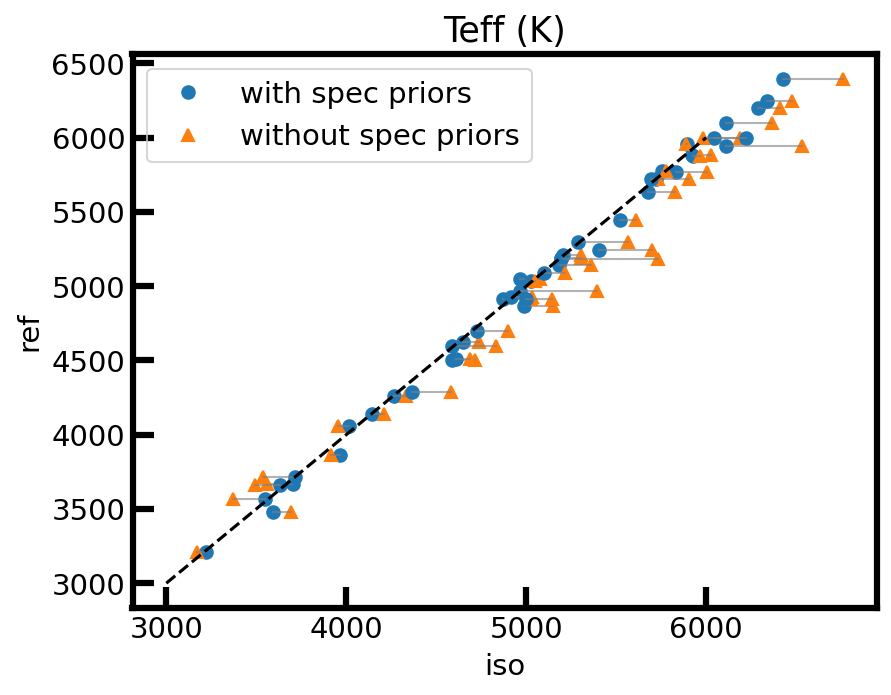

In [115]:
import matplotlib.pyplot as pl

param = 'Teff'
unit = 'K'

for i,row in df_input.iterrows():
    p1 = Path(outdir, row.hostname, 'with_spec_priors')
    fp_txt1 = p1.joinpath('star_params_comparison.txt')
    r1 = pd.read_csv(fp_txt1, index_col=0)
    label1 = 'with spec priors' if i==0 else '_nolegend_'
    pl.plot(*r1.T[param], 'o', label=label1, c='C0')

    p2 = Path(outdir, row.hostname, 'wo_spec_priors')
    fp_txt2 = p2.joinpath('star_params_comparison.txt')
    r2 = pd.read_csv(fp_txt2, index_col=0)
    label2 = 'without spec priors' if i==0 else '_nolegend_'
    pl.plot(*r2.T[param], '^', label=label2, c='C1')

    # Add line connecting the two points
    x_vals = [r1.T[param].iloc[0], r2.T[param].iloc[0]]
    y_vals = [r1.T[param].iloc[1], r2.T[param].iloc[1]]
    pl.plot(x_vals, y_vals, c='gray', lw=1, alpha=0.6)
pl.legend()
x = np.linspace(3000, 6000, 100)
pl.plot(x, x, ls='--', c='k')
# pl.xlim(4, 5)
pl.xlabel(r1.T[param].index[0])
pl.ylabel(r1.T[param].index[1])
pl.title(f"{param} ({unit})")